# Evaluating parameter quality at utility scale

In this notebook we show that we can still gauge the quality of the QAOA parameters at utility-scale. We do this with a 100 node graph with depth-one QAOA. This setting allows a direct comparison between the noisy samples and the noiseless energy which is efficiently and exactly computable for depth-one.
We maximize the energy to maximize the cut value. Each edge $(i,j)$ in the unweighted graph gives a term $-Z_iZ_j/2$ in the cost Hamiltonian $H_C$. The energy is related to the cut value by $C=\langle H_C\rangle+|E|/2$.

In [245]:
import time
import networkx as nx
import numpy as np

from qiskit import transpile
from qiskit.transpiler.passes.routing.commuting_2q_gate_routing import SwapStrategy

from qaoa_training_pipeline.training import DepthOneScanTrainer
from qaoa_training_pipeline.evaluation import EfficientDepthOneEvaluator
from qaoa_training_pipeline.visualization.plotting import plot_cdf
from qaoa_training_pipeline.utils.graph_utils import solve_max_cut, graph_to_operator, load_graph
from qaoa_training_pipeline.training.parameter_extenders import interpolate

from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2

from qopt_best_practices.sat_mapping import SATMapper
from qopt_best_practices.transpilation import qaoa_swap_strategy_pm

In [405]:
graph_name = "000_100nodes_random3regular"
graph = load_graph(f"instances/random_regular/{graph_name}.json")

The graph is SAT mapped to to minimize the number of SWAP layers when executing it on hardware.

In [9]:
swap_strat = SwapStrategy.from_line(range(graph.order()))

start = time.time()
sat_graph, _, nlayers = SATMapper(timeout=2).remap_graph_with_sat(graph, swap_strat)
sat_duration = time.time() - start
print(f"Duration of SAT mapping {sat_duration:.0f} seconds")

Duration of SAT mapping 29 seconds


In [11]:
cost_op = graph_to_operator(sat_graph, pre_factor=-0.5)

We solve the MaxCut problem exactly to later compute approximation ratios.

In [236]:
max_cut, min_cut, _ = solve_max_cut(cost_op)

We will do a depth-one 2D scan to find an interesting region in parameter space to sweep.

In [18]:
trainer = DepthOneScanTrainer(EfficientDepthOneEvaluator())
result = trainer.train(cost_op, parameter_ranges=((0, np.pi/2), (0, np.pi/2)), num_points=20)

(<Figure size 640x480 with 2 Axes>, <Axes: xlabel='Gamma', ylabel='Beta'>)

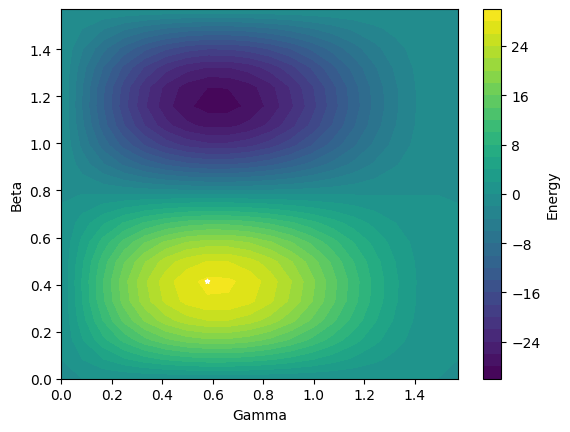

In [19]:
trainer.plot()

We now chose the optimal gamma and scan over beta values.

In [50]:
betas = np.linspace(0, np.pi/2, 8)
opt_gamma = float(result["optimized_params"][1])
test_params = [(float(beta), opt_gamma) for beta in betas]

Prepare the circuits and run them on the backend.

In [33]:
from qiskit.circuit import QuantumCircuit
from qiskit.circuit.library import QAOAAnsatz

def make_qaoa_circuit(cost_op, mode: str):

    if mode == "line":

        cost_layer = QAOAAnsatz(
            cost_op,
            reps=1,
            initial_state=QuantumCircuit(cost_op.num_qubits),
            mixer_operator=QuantumCircuit(cost_op.num_qubits),
            name="QAOA cost block",
        )
        
        pm_config = {
            "swap_strategy": SwapStrategy.from_line(range(cost_op.num_qubits)),
            "edge_coloring": {(idx, idx + 1): idx % 2 for idx in range(cost_op.num_qubits)},
            "basis_gates": ["x", "sx", "rz", "cx"]
        }
        qaoa_pm = qaoa_swap_strategy_pm(pm_config)
        
        return qaoa_pm.run(cost_layer)
    
    else:
        raise NotImplementedError("Currently, the code only transpiles to a lines.")
        

In [47]:
service = QiskitRuntimeService(instance="your-instance")

In [34]:
circ = make_qaoa_circuit(cost_op, "line")

As we can see below the circuit is large with many two-qubit gates.

In [55]:
circ.count_ops()

OrderedDict([('cx', 4926),
             ('rz', 150),
             ('h', 100),
             ('rx', 100),
             ('measure', 100)])

In [31]:
circ.draw("mpl", fold=False)

In [48]:
backend = service.backend("ibm_fez")
sampler = SamplerV2(mode=backend)

In [53]:
isa_circ = transpile(circ, backend)

In [68]:
import matplotlib.pyplot as plt

from qaoa_training_pipeline.visualization.plotting import plot_cdf

from qopt_best_practices.cost_function.cost_utils import counts_to_maxcut_cost

In [58]:
job = sampler.run([(isa_circ, params) for params in test_params], shots=2**16)

In [59]:
job.job_id()

'd1nsref6d0hc73b6fmf0'

In [61]:
results = job.result()

We save the data to a file.

In [407]:
import json
from qiskit_ibm_runtime import RuntimeEncoder

date = job.creation_date.strftime("%Y%m%d")

with open(f"data/hardware/{date}_utility_scale_test_{job.job_id()}_{graph_name}.json", "w") as file:
    json.dump(job.result(), file, cls=RuntimeEncoder)

In [62]:
mc_costs = [counts_to_maxcut_cost(sat_graph, res.data.c.get_counts()) for res in results]

In [306]:
def quantile(func_counts, alpha):
    x_vals = sorted(func_counts.keys())
    y_vals = np.cumsum([func_counts[x] for x in x_vals])
    idx = np.argmin(abs(y_vals - alpha))
    return x_vals[idx]

def mean_obj(func_counts):
    return sum([k*v for k, v in func_counts.items()])

def standard_error_mean(counts, num_shots):
    mean = mean_obj(counts)
    return np.sqrt(sum([prob * (val - mean)**2 for val, prob in counts.items()])/ num_shots)

In [317]:
medians = np.array([100*quantile(mc_cost, 0.5)/max_cut for mc_cost in mc_costs])
q25s = np.array([100*quantile(mc_cost, 0.25)/max_cut for mc_cost in mc_costs])
q75s = np.array([100*quantile(mc_cost, 0.75)/max_cut for mc_cost in mc_costs])
yerrs = np.array([medians - q25s, q75s - medians])

means = [100*mean_obj(mc_cost)/max_cut for mc_cost in mc_costs]
sems = np.array([100*standard_error_mean(mc_cost, results[0].data.c.num_shots)/max_cut for idx, mc_cost in enumerate(mc_costs)])

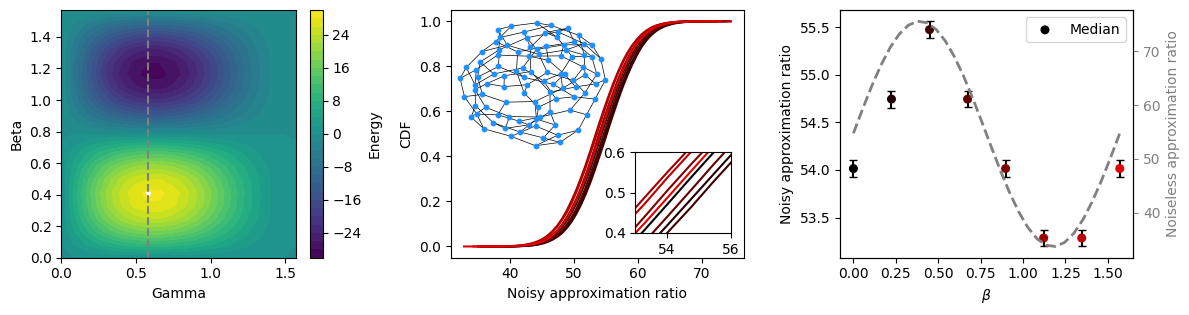

In [397]:
evaluator = EfficientDepthOneEvaluator()

fine_betas = np.linspace(0, np.pi/2, 30)

fig, axs = plt.subplots(1, 3, figsize=(12, 3.25))
axs = axs.flatten()

axs[0].vlines(opt_gamma, betas[0], betas[-1], ls="--", color="grey")
trainer.plot(fig=fig, axis=axs[0])

ax4 = axs[1].inset_axes((0.63, 0.1, 0.325, 0.325), zorder=5)

colors = [(1.0 * idx / len(mc_costs), 0, 0) for idx in range(len(mc_costs))]
for idx, mc_cost in enumerate(mc_costs):
    plot_cdf({k/max_cut*100: v for k, v in mc_cost.items()}, axis=axs[1], color=colors[idx])
    plot_cdf({k/max_cut*100: v for k, v in mc_cost.items()}, axis=ax4, color=colors[idx])

axs[1].set_xlabel("Noisy approximation ratio")
axs[1].set_ylabel("CDF")

ax2 = axs[2].twinx()
axs[2].errorbar([val[0] for val in test_params], medians, yerr=4*1.253*sems, marker="None", c="k", ls="none", zorder=-10, capsize=3)
axs[2].scatter([val[0] for val in test_params], medians, marker="o", c=colors, s=30, label="Median")
approx_ratios = [100*(evaluator.evaluate(cost_op, [beta, opt_gamma]) + len(sat_graph.edges())/2)/max_cut for beta in fine_betas]
ax2.plot(fine_betas, approx_ratios, c="grey", ls="--", lw=2, zorder=-20)
axs[2].set_xlabel(r"$\beta$")
axs[2].set_ylabel("Noisy approximation ratio")
ax2.set_ylabel("Noiseless approximation ratio", color="grey")
ax2.tick_params(axis="y", colors="grey")
axs[2].legend()

ax4.set_xlim([53, 56])
ax4.set_ylim([0.4, 0.6])

ax3 = axs[1].inset_axes((-0.02, 0.4, 0.6, 0.6), zorder=5)
nx.draw_kamada_kawai(graph, ax=ax3, node_size=10, node_color="dodgerblue", width=0.5)

fig.tight_layout()
fig.savefig("figures/testing_on_hardware.pdf", bbox_inches="tight")